In [1]:
# 确保在 import torch 之前设置环境变量（Colab 请从此单元开始运行）
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"          # 同步报错，定位真实出错行
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8" # 确定性 matmul 需求
print("CUDA_LAUNCH_BLOCKING:", os.environ["CUDA_LAUNCH_BLOCKING"])
print("CUBLAS_WORKSPACE_CONFIG:", os.environ["CUBLAS_WORKSPACE_CONFIG"])


CUDA_LAUNCH_BLOCKING: 1
CUBLAS_WORKSPACE_CONFIG: :4096:8


In [2]:
# for google colab


import sys, torch, os, platform

from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/Hybrid_Unlearning/')
print("Current working directory:", os.getcwd())

print("Python exe:", sys.executable)
print("PyTorch:", torch.__version__)
print("torch.version.cuda:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Mounted at /content/drive
Current working directory: /content/drive/MyDrive/Hybrid_Unlearning
Python exe: /usr/bin/python3
PyTorch: 2.9.0+cu126
torch.version.cuda: 12.6
CUDA available: True
CUDA_VISIBLE_DEVICES: None
GPU: NVIDIA A100-SXM4-80GB


In [3]:
import sys, torch, os, platform
print("Python exe:", sys.executable)
print("PyTorch:", torch.__version__)
print("torch.version.cuda:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python exe: /usr/bin/python3
PyTorch: 2.9.0+cu126
torch.version.cuda: 12.6
CUDA available: True
CUDA_VISIBLE_DEVICES: None
GPU: NVIDIA A100-SXM4-80GB


In [4]:
# 删除上次运行产生的目录
import shutil
import os

dirs_to_remove = ['fl_history', 'models', 'triggered']
for dir_name in dirs_to_remove:
    if os.path.exists(dir_name) and os.path.isdir(dir_name):
        shutil.rmtree(dir_name)
        print(f"Deleted directory: {dir_name}")
    else:
        print(f"Directory not found or already deleted: {dir_name}")

Deleted directory: fl_history
Deleted directory: models
Directory not found or already deleted: triggered


In [5]:
# 确定性与 DataLoader 复现性（需在创建模型/DataLoader 前执行）
import torch, numpy as np, random

torch.use_deterministic_algorithms(True)
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# 为 DataLoader 提供固定的随机生成器与 worker 种子
try:
    SEED
except NameError:
    SEED = 42

g = torch.Generator()
g.manual_seed(SEED)

def _seed_worker(worker_id):
    base = SEED
    np.random.seed(base + worker_id)
    random.seed(base + worker_id)


/usr/local/lib/python3.12/dist-packages/torch/backends/__init__.py:46: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  self.setter(val)


In [6]:
# 导入库并设置随机种子
import os, sys, copy, random
import time, pickle, argparse
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader, Dataset, Subset, TensorDataset, random_split
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score
from typing import Dict, List, Tuple, Optional, Any

from fedavg import fedavg, get_model_weights, set_model_weights
from model import model_init
from server import Server
from data_preprocess import get_partitioned_data, load_dataset, create_dirichlet_splits, create_iid_splits, create_data_loaders
from backdoor import BackdoorAttack, evaluate_backdoor
from federaser import FedEraser
from hybrideraser import HybridEraser
from kd import subtract_model, knowledge_distillation
from fedrecover import FedRecover

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [7]:
config = {
    "dataset": "emnist_balanced",            # 'mnist' | 'fashion_mnist' | 'cifar10' | 'cifar100' emnist_balanced， svhn
    "model_name": "resnet18", # 34 50
    "num_clients": 50,
    "batch_size": 128,
    "partition_type": "non-iid",   # 'iid' or 'non-iid'
    "epochs": 10,
    "rounds": 10,
    "lr": 0.01,
    "momentum": 0.9,
    "save_dir": "./models",
    "history_dir": "./fl_history",


    # evaluating
    "backdoor_client": 0,
    "backdoor_target": 7,
    "backdoor_ratio": 0.3,
    "backdoor_pattern": "square",
    # "backdoor_pattern": "dba_dice6_all",
    # "backdoor_size": 5, # for mnist
    "backdoor_size": 5, # for cifar

    # triggers
    "backdoor_config": {
        # mnist-basic
        0: {'target_label': 7, 'poison_ratio': 0.3, 'trigger_pattern': 'square', 'trigger_size': 5},
        1: {'target_label': 7, 'poison_ratio': 0.3, 'trigger_pattern': 'square', 'trigger_size': 5},
        2: {'target_label': 7, 'poison_ratio': 0.3, 'trigger_pattern': 'square', 'trigger_size': 5},
        3: {'target_label': 7, 'poison_ratio': 0.3, 'trigger_pattern': 'square', 'trigger_size': 5},
        4: {'target_label': 7, 'poison_ratio': 0.3, 'trigger_pattern': 'square', 'trigger_size': 5},
        5: {'target_label': 7, 'poison_ratio': 0.3, 'trigger_pattern': 'square', 'trigger_size': 5},
        6: {'target_label': 7, 'poison_ratio': 0.3, 'trigger_pattern': 'square', 'trigger_size': 5},
        7: {'target_label': 7, 'poison_ratio': 0.3, 'trigger_pattern': 'square', 'trigger_size': 5},
        8: {'target_label': 7, 'poison_ratio': 0.3, 'trigger_pattern': 'square', 'trigger_size': 5},
        9: {'target_label': 7, 'poison_ratio': 0.3, 'trigger_pattern': 'square', 'trigger_size': 5},
        # mnist-dba
        # 0: {'target_label': 7, 'poison_ratio': 0.1, 'trigger_pattern': 'dba_dice6_bar1', 'trigger_size': 3},
        # 1: {'target_label': 7, 'poison_ratio': 0.1, 'trigger_pattern': 'dba_dice6_bar2', 'trigger_size': 3},
        # 2: {'target_label': 7, 'poison_ratio': 0.1, 'trigger_pattern': 'dba_dice6_bar3', 'trigger_size': 3},
        # 3: {'target_label': 7, 'poison_ratio': 0.1, 'trigger_pattern': 'dba_dice6_bar4', 'trigger_size': 3},
        # 4: {'target_label': 7, 'poison_ratio': 0.1, 'trigger_pattern': 'dba_dice6_bar5', 'trigger_size': 3},
        # 5: {'target_label': 7, 'poison_ratio': 0.1, 'trigger_pattern': 'dba_dice6_bar6', 'trigger_size': 3},

        # # cifar
        # 0: {'target_label': 7, 'poison_ratio': 0.25, 'trigger_pattern': 'square', 'trigger_size': 4},

        # # cifar-dba
        # 0: {'target_label': 7, 'poison_ratio': 0.25, 'trigger_pattern': 'dba_dice6_bar1', 'trigger_size': 4},
        # 1: {'target_label': 7, 'poison_ratio': 0.25, 'trigger_pattern': 'dba_dice6_bar2', 'trigger_size': 4},
        # 2: {'target_label': 7, 'poison_ratio': 0.25, 'trigger_pattern': 'dba_dice6_bar3', 'trigger_size': 4},
        # 3: {'target_label': 7, 'poison_ratio': 0.25, 'trigger_pattern': 'dba_dice6_bar4', 'trigger_size': 4},
        # 4: {'target_label': 7, 'poison_ratio': 0.25, 'trigger_pattern': 'dba_dice6_bar5', 'trigger_size': 4},
        # 5: {'target_label': 7, 'poison_ratio': 0.25, 'trigger_pattern': 'dba_dice6_bar6', 'trigger_size': 4},
    },


    "unlearn_method": "all",   # 可选："federaser" | "fedrecover" | "kd" | "hybrideraser" | "all"
    "unlearn_clients": [0,1,2,3,4,5,6,7,8,9],

    # Federaser（已有）
    "federaser_epochs": 2,
    "federaser_max_rounds": 40,

    # FedRecover 参数
    "fedrecover_warmup_rounds": 1,        # 预热轮次（混合：估计+纠偏，严格20步）
    "fedrecover_correction_period": 5,    # 每5轮纠偏（第5、10轮）
    "fedrecover_final_tuning_rounds": 1,  # 最终微调（锚点）
    "fedrecover_buffer_size": 5,          # L-BFGS缓冲区大小
    "fedrecover_abnorm_threshold": 40.0,  # 异常更新阈值（范数差）
    "fedrecover_specific_rounds": None,   # 指定恢复的轮次列表；None 表示使用 max_rounds/全部
    "fedrecover_epochs": 5,               # 每次锚点本地epoch：4次×5=20步

    "kd_epochs": 20,
    "kd_temperature": 0.5,
    "kd_lr": 0.01,
    "kd_alpha": 1.0,
    "kd_clean_clients": [0,1,2,3,4,5,6,7,8,9],  # KD 集由“干净客户端序列”中的这些位置下标所对应的客户端的全部数据拼接而成

    "hybrid_branch": 'federaser+kd',
    "hybrid_kd_epochs_per_round": 2,
    "hybrid_aggregation_interval": 1,


    # ===== 预设参数：当 train = 5 epochs * 10 rounds，20%预算 (T=10) =====
    # 取消以下注释即可直接启用该预设（放在此处保证覆盖上方同名键）：
    # "federaser_epochs": 1,                  # FedEraser: 1×10=10
    # "kd_epochs": 10,                        # KD: 10 epoch
    # "fedrecover_warmup_rounds": 1,          # FedRecover（估计+纠偏，严格10步）
    # "fedrecover_correction_period": 3,      # 在第3、6、9轮纠偏，共3次
    # "fedrecover_final_tuning_rounds": 1,
    # "fedrecover_epochs": 2,                 # 锚点=1+3+1=5；5×2=10

  # Default Parameters
  # use_dynamic_alpha: True
  # dynamic_alpha_min: 0.05
  # dynamic_alpha_max: 0.95
  # dynamic_alpha_smooth: 0.85
  # dynamic_alpha_max_step: 0.15
  # dynamic_alpha_gain: 2.0
  # dynamic_alpha_base_sensitivity: 0.5
  # dynamic_alpha_tau: 20
  # dynamic_alpha_bias: 0.0
  # dynamic_alpha_beta: 0.7
  # dynamic_alpha_window: 5
  # dynamic_alpha_trend_weight: 0.15
  # dynamic_alpha_trend_scale: 4.0
  # 其余相关默认项（同一文件）：
  # aggregation_alpha: 0.5
  # accuracy_only_agg: False
  # accuracy_only_mode: "ratio"
  # val_split_ratio: 0.05
  # kd_split_ratio: 0.10  [deprecated] KD 不再从全量训练集中切分，改为从干净客户端拼接

  # --------------------------- 计算公式（仅注释说明） ---------------------------
  # 最终聚合（Fed为alpha，KD为1-alpha）：
  #   W_hybrid = alpha * W_fed + (1 - alpha) * W_kd
  #
  # EMA平滑验证精度（降低噪声），beta in (0,1)：
  #   fed_ema_t = beta * fed_ema_(t-1) + (1 - beta) * fed_acc_t
  #   kd_ema_t  = beta * kd_ema_(t-1)  + (1 - beta) * kd_acc_t
  #
  # 趋势斜率（窗口window）：
  #   s_fed = (fed_ema_t - fed_ema_(t-k)) / k,   s_kd = (kd_ema_t - kd_ema_(t-k)) / k
  #   其中 k = min(window, t)
  #
  # 相位衰减（早期更敏感），tau > 0：
  #   phi = exp(- t / tau)
  #
  # 当前实力相对差（避免量纲影响）：
  #   A_bar = (fed_acc_t + kd_acc_t) / 2 + eps
  #   d = (fed_acc_t - kd_acc_t) / A_bar
  #
  # 趋势项（限制在 [-trend_weight, trend_weight]）：
  #   Delta_s = s_fed - s_kd
  #   T = trend_weight * tanh(trend_scale * Delta_s)
  #
  # 目标alpha（未平滑前），sensitivity = base_sensitivity * phi：
  #   alpha_target = 0.5 + bias + gain * (sensitivity * d + phi * T)
  #   alpha_target = clip(alpha_target, alpha_min, alpha_max)
  #
  # 一阶平滑与单步限制得到最终alpha：
  #   alpha_smoothed = smooth * alpha_prev + (1 - smooth) * alpha_target
  #   alpha = clip(alpha_smoothed, alpha_prev - max_step, alpha_prev + max_step)
  #   alpha = clip(alpha, alpha_min, alpha_max)

    "retrain_rounds": 10,
    "perform_retrain": True,

    "skip_training": False,
    "model_path": "./models/mnist_model.pth",
    "history_path": "./fl_history/complete_history_r0-r9.pkl",
    "cut_ratio": 1,
    "dirichlet_alpha": 0.5,

    "val_split_ratio": 0.05,  # 5% set for validation
    "kd_split_ratio": 0.05,  # [deprecated] 旧版从全量训练集中按比例切分 KD（当前已不再使用）

    "debug_baseline_only": True,

}

In [8]:
# 定义触发器函数
import random
def _apply_trigger(img, pattern='square', size=3):
    img = img.clone()
    c, h, w = img.shape
    color = torch.ones(c) if c == 1 else torch.tensor([1.0, 0, 0])
    if pattern == 'square':
        y, x = h - size - 1, w - size - 1
        img[:, y:y+size, x:x+size] = color.view(c, 1, 1)
    elif pattern == 'cross':
        cx, cy = w // 2, h // 2
        s = size // 2
        img[:, cy-s:cy+s+1, cx] = color.view(c, 1)
        img[:, cy, cx-s:cx+s+1] = color.view(c, 1)
    elif pattern == 'dynamic_square':
        y = random.randint(0, h - size)
        x = random.randint(0, w - size)
        img[:, y:y+size, x:x+size] = color.view(c, 1, 1)
    elif pattern == 'dynamic_cross':
        y = random.randint(0, h - size)
        x = random.randint(0, w - size)
        s = size // 2
        cy = y + s
        cx = x + s
        img[:, cy-s:cy+s+1, cx] = color.view(c, 1)
        img[:, cy, cx-s:cx+s+1] = color.view(c, 1)
    elif pattern == 'chessboard':
        img[::2, ::2] = color.view(c, 1, 1)
    elif pattern == 'watermark_full':
        img[:] = color.view(c, 1, 1)
    elif pattern == 'flower':
        y, x = h - size - 1, w - size - 1
        img[:, y:y+size, x:x+size] = color.view(c, 1, 1)
        s = size // 2
        img[:, y+s, x:x+size] = color.view(c, 1)
        img[:, y:y+size, x+s] = color.view(c, 1)
    return img

In [9]:
# 本地训练，返回权重与样本数
def train_local_model(model, dataloader, config, device):
    model.train()
    opt = torch.optim.SGD(model.parameters(), lr=config["lr"], momentum=config["momentum"])
    for _ in range(config["epochs"]):
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            out = model(x)
            # 断言：标签与输出类别数一致，且 dtype 正确
            assert y.dtype == torch.long, f"Label dtype must be Long, got {y.dtype}"
            assert y.max().item() < out.shape[1], f"Label max {y.max().item()} >= num_classes {out.shape[1]}"
            loss = F.cross_entropy(out, y)
            loss.backward()
            opt.step()
    return get_model_weights(model), len(dataloader.dataset)

In [10]:
# 新流程调整：VAL 从“全量干净训练集”中切分；KD 不再从全量切分，而是在划分客户端并注入后门后，从“干净客户端（未在 unlearn_clients 中）”按位置选出若干个客户端，将其全部数据拼接为 KD 集。
print("Creating VAL from CLEAN TRAINSET; KD will be built by concatenating selected clean clients after partitioning and poisoning (IID/Dirichlet)")

# 1) 加载干净训练集与测试集（使用与原流程一致的变换）
train_dataset_full, test_dataset = load_dataset(config["dataset"], data_dir=config.get("data_dir", "./data"))

# 2) 先从全量训练集分出 KD/VAL（分层采样，IID）
def get_labels(dataset):
    if hasattr(dataset, 'targets'):
        labels = dataset.targets
        if isinstance(labels, torch.Tensor):
            return labels.numpy()
        return np.array(labels)
    elif hasattr(dataset, 'labels'):
        labels = dataset.labels
        if isinstance(labels, torch.Tensor):
            return labels.numpy()
        return np.array(labels)
    else:
        labels = []
        for i in range(len(dataset)):
            _, label = dataset[i]
            labels.append(label)
        return np.array(labels)

labels_full = get_labels(train_dataset_full)
all_idx = np.arange(len(train_dataset_full))
seed = config.get("seed", 42)
val_ratio = config.get("val_split_ratio", 0.05)
kd_ratio = config.get("kd_split_ratio", 0.10)  # 兼容旧配置（已废弃）；当前 KD 由干净客户端拼接获得，此字段不再使用

from sklearn.model_selection import train_test_split
# 2.1 先切 VAL
remain_idx, val_idx = train_test_split(
    all_idx, test_size=val_ratio, stratify=labels_full, random_state=seed
)
# KD 不再从训练集中切分，改为从各个干净客户端抽取后拼接
train_idx = remain_idx

from torch.utils.data import Subset
train_dataset_remain = Subset(train_dataset_full, train_idx)
val_subset = Subset(train_dataset_full, val_idx)

# 打印 KD/VAL 分布
def check_distribution(subset, name, base_labels):
    if hasattr(subset, 'indices'):
        subset_indices = subset.indices
    else:
        subset_indices = list(range(len(subset)))
    subset_labels = base_labels[subset_indices]
    unique, counts = np.unique(subset_labels, return_counts=True)
    total = len(subset_labels)
    dist_dict = {int(u): int(c) for u, c in zip(unique, counts)}
    percentages = {int(u): f"{100*c/total:.1f}%" for u, c in zip(unique, counts)}
    print(f"{name} ({total}样本) 类别分布: {dist_dict}")
    print(f"{name} 类别比例: {percentages}")

print("\n验证IID分布 (CLEAN TRAINSET):")
check_distribution(val_subset, "验证集", labels_full)

# 3) 对“剩余训练集”进行客户端划分
num_clients = config["num_clients"]
alpha = config.get("dirichlet_alpha")
if alpha is not None:
    # 对“剩余训练集”的原始索引做 Dirichlet 划分（基于全量标签）
    labels_remain_arr = labels_full[train_idx]
    classes = np.unique(labels_remain_arr)
    # 每个类别在剩余索引中的原始索引列表
    class_indices = [train_idx[labels_remain_arr == c] for c in classes]
    for idx_list in class_indices:
        np.random.shuffle(idx_list)
    client_indices = [[] for _ in range(num_clients)]
    label_distribution = np.random.dirichlet([alpha] * num_clients, len(classes))
    for idxs, fracs in zip(class_indices, label_distribution):
        split_points = (np.cumsum(fracs)[:-1] * len(idxs)).astype(int)
        splits = np.split(idxs, split_points)
        for i, part in enumerate(splits):
            client_indices[i].extend(part.tolist())
    partitions = [Subset(train_dataset_full, inds) for inds in client_indices]
else:
    if config.get("partition_type") == 'iid':
        partitions = create_iid_splits(train_dataset_remain, num_clients)
    else:
        # 未指定 alpha 的 non-iid，原逻辑退回 IID
        partitions = create_iid_splits(train_dataset_remain, num_clients)

# 4) 对指定客户端注入后门（仅对“剩余训练集”的分片注入）
backdoor_config = config.get("backdoor_config")
if backdoor_config:
    for client_id, params in backdoor_config.items():
        if 0 <= client_id < num_clients:
            target_label = params.get('target_label', 7)
            poison_ratio = params.get('poison_ratio', 0.3)
            trigger_pattern = params.get('trigger_pattern')
            trigger_size = params.get('trigger_size', 5)
            print(f"Implementing backdoor attack on client {client_id}")
            print(f"Backdoor parameters for client {client_id}: target_label={target_label}, poison_ratio={poison_ratio}, trigger_pattern={trigger_pattern}, trigger_size={trigger_size}")
            attack = BackdoorAttack(target_label=target_label,
                                    poison_ratio=poison_ratio,
                                    trigger_pattern=trigger_pattern,
                                    trigger_size=trigger_size,
                                    dataset_name=config["dataset"],
                                    trigger_color='white')
            partitions[client_id] = attack.poison_dataset(partitions[client_id])
        else:
            print(f"Warning: Invalid backdoor client id {client_id} (ignored).")

# 5) 构建 DataLoader（训练/测试）
#    与 create_data_loaders 的行为保持一致（Windows 下 worker=0）
import os as _os
_cpu_cnt = max(_os.cpu_count() or 2, 2)
_use_workers = 0 if _os.name == 'nt' else min(_cpu_cnt, 8)
_base_kwargs = dict(
    batch_size=config.get("batch_size", 32),
    num_workers=_use_workers,
)
if _use_workers > 0:
    # 避免在 Colab 中持久化 worker 导致内存不释放
    _base_kwargs.update(pin_memory=True, persistent_workers=False, prefetch_factor=2)

train_loaders = [DataLoader(partition, shuffle=True, **_base_kwargs) for partition in partitions]

# 测试集 DataLoader
test_loader = DataLoader(test_dataset, shuffle=False, **_base_kwargs)

from torch.utils.data import ConcatDataset  # 用于将多个客户端的数据集合并为一个 KD 数据集

# 从配置项选取“若干个干净客户端”的全部数据并拼接为 KD 集
# - clean 客户端定义：不在 unlearn_clients 列表中的客户端（视为干净客户端）
# - kd_clean_clients: 给出的是“在 clean 客户端序列中的位置下标”，例如 [0,1,2,3]
#   表示取前 4 个干净客户端（对应到真实 client id 后再取其全部数据）
# - 这样可以方便在不同 unlearn_clients 设置下，始终“按位置”选择干净客户端
unlearn_set = set(config.get("unlearn_clients", []))
available_clean_ids = [cid for cid in range(num_clients) if cid not in unlearn_set]

kd_pos_list = config.get("kd_clean_clients", [])
if not kd_pos_list:
    kd_pos_list = [0] if available_clean_ids else []  # 兜底：若未指定则选第一个干净客户端

selected_clean_ids = []
for pos in kd_pos_list:
    if isinstance(pos, int) and 0 <= pos < len(available_clean_ids):
        selected_clean_ids.append(available_clean_ids[pos])

# 将所选干净客户端的“全部数据分片”进行拼接
clean_kd_datasets = [partitions[cid] for cid in selected_clean_ids] if selected_clean_ids else []
if len(clean_kd_datasets) == 0:
    # 兜底策略：若没有可用干净客户端，则退化为使用第一个可用分片
    kd_subset = partitions[available_clean_ids[0]] if available_clean_ids else partitions[0]
else:
    kd_subset = ConcatDataset(clean_kd_datasets)

print(f"[KD] Using clean clients (by position): {kd_pos_list} -> client IDs: {selected_clean_ids}")

# KD/VAL DataLoader（不参与训练，避免泄露）
kd_loader  = DataLoader(kd_subset,  shuffle=True,  **_base_kwargs)
val_loader = DataLoader(val_subset, shuffle=False, **_base_kwargs)

print(f"test(full)={len(test_dataset)}, kd={len(kd_subset)}, val={len(val_subset)}.")

Creating VAL from CLEAN TRAINSET; KD will be built by concatenating selected clean clients after partitioning and poisoning (IID/Dirichlet)

验证IID分布 (CLEAN TRAINSET):
验证集 (5640样本) 类别分布: {0: 120, 1: 120, 2: 120, 3: 120, 4: 120, 5: 120, 6: 120, 7: 120, 8: 120, 9: 120, 10: 120, 11: 120, 12: 120, 13: 120, 14: 120, 15: 120, 16: 120, 17: 120, 18: 120, 19: 120, 20: 120, 21: 120, 22: 120, 23: 120, 24: 120, 25: 120, 26: 120, 27: 120, 28: 120, 29: 120, 30: 120, 31: 120, 32: 120, 33: 120, 34: 120, 35: 120, 36: 120, 37: 120, 38: 120, 39: 120, 40: 120, 41: 120, 42: 120, 43: 120, 44: 120, 45: 120, 46: 120}
验证集 类别比例: {0: '2.1%', 1: '2.1%', 2: '2.1%', 3: '2.1%', 4: '2.1%', 5: '2.1%', 6: '2.1%', 7: '2.1%', 8: '2.1%', 9: '2.1%', 10: '2.1%', 11: '2.1%', 12: '2.1%', 13: '2.1%', 14: '2.1%', 15: '2.1%', 16: '2.1%', 17: '2.1%', 18: '2.1%', 19: '2.1%', 20: '2.1%', 21: '2.1%', 22: '2.1%', 23: '2.1%', 24: '2.1%', 25: '2.1%', 26: '2.1%', 27: '2.1%', 28: '2.1%', 29: '2.1%', 30: '2.1%', 31: '2.1%', 32: '2.1%', 33:

In [11]:
# 复写 DataLoader，加入固定 generator 与 worker_init_fn，确保可复现
import os as _os
_cpu_cnt = max(_os.cpu_count() or 2, 2)
_use_workers = 0 if _os.name == 'nt' else min(_cpu_cnt, 8)
_base_kwargs2 = dict(
    batch_size=config.get("batch_size", 32),
    num_workers=_use_workers,
)
if _use_workers > 0:
    # 避免在 Colab 中持久化 worker 导致内存不释放
    _base_kwargs2.update(pin_memory=True, persistent_workers=True, prefetch_factor=2)

_base_kwargs2.update(dict(worker_init_fn=_seed_worker, generator=g))

# 若此前已创建过 DataLoader，尽快释放引用
try:
    del train_loaders, test_loader, kd_loader, val_loader
except NameError:
    pass
import gc as _gc
_gc.collect()
import torch as _t
if _t.cuda.is_available():
    _t.cuda.empty_cache()

train_loaders = [DataLoader(partition, shuffle=True, **_base_kwargs2) for partition in partitions]

test_loader = DataLoader(test_dataset, shuffle=False, **_base_kwargs2)

kd_loader  = DataLoader(kd_subset,  shuffle=True,  **_base_kwargs2)
val_loader = DataLoader(val_subset, shuffle=False, **_base_kwargs2)


In [12]:
global_model = model_init(config).to("cuda" if torch.cuda.is_available() else "cpu")
train_accuracy_list, train_bd_sr_list = [], []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
start_train = time.time()

server = Server(config)
global_model = model_init(config).to(device)

for rnd in range(config["rounds"]):
    print(f"\n--- Round {rnd+1} ---")
    client_weights, sample_sizes = [], []
    for cid, train_loader in enumerate(train_loaders):
        local_model = copy.deepcopy(global_model)
        w, n = train_local_model(local_model, train_loader, config, device)
        client_weights.append(w); sample_sizes.append(n)
        server.store_client_updates(cid, w, n)

    global_weights = fedavg(client_weights, sample_sizes)
    set_model_weights(global_model, global_weights)
    server.store_aggregation_result(global_weights)
    server.next_round()

    global_model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out = global_model(x)
            # 断言：标签与输出类别数一致，且 dtype 正确
            assert y.dtype == torch.long, f"Label dtype must be Long, got {y.dtype}"
            assert y.max().item() < out.shape[1], f"Label max {y.max().item()} >= num_classes {out.shape[1]}"
            test_loss += F.cross_entropy(out, y, reduction='sum').item()
            pred = out.argmax(dim=1, keepdim=True)
            correct += pred.eq(y.view_as(pred)).sum().item()
    test_loss /= len(test_loader.dataset)
    acc = 100. * correct / len(test_loader.dataset)
    bdsr = evaluate_backdoor(global_model, test_loader, device, target_label=config["backdoor_target"])
    print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {acc:.2f}% | BDSR: {bdsr:.2f}%")
    train_accuracy_list.append(acc); train_bd_sr_list.append(bdsr)
    os.makedirs("./models", exist_ok=True); os.makedirs("./fl_history", exist_ok=True)
    history_path = server.save_complete_history()
    model_path = os.path.join(config['save_dir'], f"{config['dataset']}_model.pth")
    torch.save(global_model.state_dict(), model_path)
    with open(history_path, "wb") as f:
        pickle.dump({
            "client_updates_history": server.client_updates_history,
            "aggregation_history": server.aggregation_history,
            "current_round": server.current_round
        }, f)
    config["model_path"] = model_path; config["history_path"] = history_path

print(f"train time: {time.time() - start_train:.4f} s")


--- Round 1 ---
Backdoor Recall (non-7 samples): 6.71%
Backdoor Precision (predicted 7): 86.60%
Test Loss: 3.4966 | Test Accuracy: 6.51% | BDSR: 6.71%
Saved complete history to /content/drive/MyDrive/fl_history/complete_history_r0-r0.pkl

--- Round 2 ---
Backdoor Recall (non-7 samples): 5.43%
Backdoor Precision (predicted 7): 71.66%
Test Loss: 1.1490 | Test Accuracy: 65.86% | BDSR: 5.43%
Saved complete history to /content/drive/MyDrive/fl_history/complete_history_r0-r1.pkl

--- Round 3 ---
Backdoor Recall (non-7 samples): 9.61%
Backdoor Precision (predicted 7): 81.56%
Test Loss: 0.8014 | Test Accuracy: 75.05% | BDSR: 9.61%
Saved complete history to /content/drive/MyDrive/fl_history/complete_history_r0-r2.pkl

--- Round 4 ---
Backdoor Recall (non-7 samples): 29.64%
Backdoor Precision (predicted 7): 93.17%
Test Loss: 0.7105 | Test Accuracy: 77.63% | BDSR: 29.64%
Saved complete history to /content/drive/MyDrive/fl_history/complete_history_r0-r3.pkl

--- Round 5 ---
Backdoor Recall (non-7

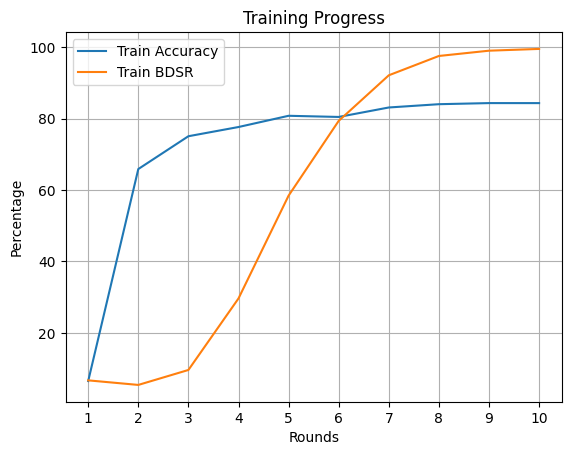

In [13]:
# 可视化训练结果
plt.figure()
plt.plot(range(1, len(train_accuracy_list)+1), train_accuracy_list, label='Train Accuracy')
plt.plot(range(1, len(train_bd_sr_list)+1), train_bd_sr_list, label='Train BDSR')
plt.xlabel("Rounds"); plt.ylabel("Percentage")
plt.title("Training Progress"); plt.xticks(range(1, len(train_accuracy_list) + 1))
plt.legend(); plt.grid(True); plt.show()
# 释放图像内存
plt.close()

In [ ]:
# Unlearning 阶段
method = config["unlearn_method"]
assert method in {"federaser", "fedrecover", "kd", "hybrideraser",  "all"}
if not config.get("skip_training"):
    config["model_path"] = config.get("model_path") or f"./models/{config['dataset']}_{method}_model.pth"
    config["history_path"] = config.get("history_path") or f"./fl_history/{config['dataset']}_{method}_history.pkl"
    os.makedirs(os.path.dirname(config["model_path"]), exist_ok=True)
    os.makedirs(os.path.dirname(config["history_path"]), exist_ok=True)

unlearned_dir = os.path.join(config["save_dir"], "unlearned")
os.makedirs(unlearned_dir, exist_ok=True)
unlearned_model_path = os.path.join(unlearned_dir, f"{config['dataset']}_{method}_unlearned_c{config['unlearn_clients']}.pth")

print("\n=== Starting Unlearning Phase ===")
# 共享随机初始化（所有unlearn方法从同一初始化出发）
shared_init_model = model_init(config).to(device)
shared_init_state = {k: v.clone().detach().cpu() for k, v in shared_init_model.state_dict().items()}

erased_client = config["backdoor_client"]
fed_accuracy_list, fed_bd_sr_list = [], []
fr_accuracy_list, fr_bd_sr_list = [], []
kd_accuracy_list, kd_bd_sr_list = [], []
hybrid_accuracy_list, hybrid_bd_sr_list = [], []

if method in {"federaser", "all"}:
    start_fed = time.time()
    eraser = FedEraser(model_path=config["model_path"], history_path=config["history_path"],
                       config=config, history_dir=config["history_dir"], save_dir=unlearned_dir, device=device)
    erased_weights_fed, history_fed = eraser.run(
        clients_to_remove=config["unlearn_clients"], train_loaders=train_loaders, test_loader=test_loader,
        save_model_path=os.path.join(unlearned_dir, f"federaser_{config['dataset']}.pth"),
        batch_size=config["batch_size"], lr=config["lr"], epochs=config["federaser_epochs"],
        unlearn_rounds=config.get("federaser_specific_rounds"), max_rounds=config.get("federaser_max_rounds", 10),
        init_state_dict=shared_init_state
    )
    print(f"[FedEraser] Time: {time.time() - start_fed:.2f}s")
    if history_fed:
        fed_accuracy_list = history_fed.get("test_accuracy", [])
        fed_bd_sr_list = history_fed.get("backdoor_success_rate", [])
    # 显式保存 FedEraser 结果模型
    fed_model_to_save = model_init(config).to(device)
    set_model_weights(fed_model_to_save, erased_weights_fed, device)
    fed_save_path = os.path.join(unlearned_dir, f"federaser_{config['dataset']}.pth")
    torch.save(fed_model_to_save.state_dict(), fed_save_path)
    print(f"[FedEraser] Saved to: {fed_save_path}")
    # 释放 FedEraser 阶段占用的内存
    try:
        del eraser, fed_model_to_save, erased_weights_fed, history_fed
    except Exception:
        pass
    import gc as _gc
    _gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

if method in {"fedrecover", "all"}:
    start_fr = time.time()
    recover = FedRecover(model_path=config["model_path"], history_path=config["history_path"],
                         config=config, history_dir=config["history_dir"], save_dir=unlearned_dir, device=device)
    recovered_weights_fr, history_fr = recover.run(
        clients_to_remove=config["unlearn_clients"],
        train_loaders=train_loaders,
        test_loader=test_loader,
        save_model_path=os.path.join(unlearned_dir, f"fedrecover_{config['dataset']}.pth"),
        unlearn_rounds=config.get("fedrecover_specific_rounds"),
        max_rounds=config.get("federaser_max_rounds", 10),
        lr=config.get("lr"),
        local_epochs=config.get("fedrecover_epochs", config.get("federaser_epochs", 1)),
        init_state_dict=shared_init_state
    )
    print(f"[FedRecover] Time: {time.time() - start_fr:.2f}s")
    if history_fr:
        fr_accuracy_list = history_fr.get("test_accuracy", [])
        fr_bd_sr_list = history_fr.get("backdoor_success_rate", [])
    # 显式保存 FedRecover 结果模型
    fr_model_to_save = model_init(config).to(device)
    set_model_weights(fr_model_to_save, recovered_weights_fr, device)
    fr_save_path = os.path.join(unlearned_dir, f"fedrecover_{config['dataset']}.pth")
    torch.save(fr_model_to_save.state_dict(), fr_save_path)
    print(f"[FedRecover] Saved to: {fr_save_path}")
    # 释放 FedRecover 阶段占用的内存
    try:
        del recover, fr_model_to_save, recovered_weights_fr, history_fr
    except Exception:
        pass
    import gc as _gc
    _gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()



if method in {"kd", "all"}:
    start_kd = time.time()
    erased_model_kd = model_init(config).to(device)
    erased_model_kd.load_state_dict(shared_init_state)

    # 使用“干净训练分片”构建的 KD 集（不使用测试数据）
    # kd_loader 已在数据准备阶段由 clean-train pool 构建
    print(f"[KD] Using {len(kd_loader.dataset)} clean-train samples for knowledge distillation")

    # 知识蒸馏
    erased_model_kd, history_kd = knowledge_distillation(
        teacher_model=global_model,
        student_model=erased_model_kd,
        train_loader=kd_loader,
        test_loader=test_loader,
        device=device,
        config=config
    )
    # 保存 KD 结果模型（仅当 KD 分支运行时）
    kd_save_path = os.path.join(unlearned_dir, f"kd_{config['dataset']}.pth")
    torch.save(erased_model_kd.state_dict(), kd_save_path)
    print(f"[KD] Time: {time.time() - start_kd:.2f}s")

    if history_kd:
        kd_accuracy_list = history_kd.get("test_accuracy", [])
        kd_bd_sr_list = history_kd.get("backdoor_success_rate", [])

    # 释放 KD 阶段占用的内存
    try:
        del erased_model_kd, history_kd
    except Exception:
        pass
    import gc as _gc
    _gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

if method in {"hybrideraser", "all"}:
    start_hybrid = time.time()
    hybrideraser_init_model = model_init(config).to(device)
    hybrideraser_init_model.load_state_dict(shared_init_state)
    from hybrideraser import run_hybrid_unlearning
    erased_model_hybrid, history_hybrid = run_hybrid_unlearning(
        config=config, train_loaders=train_loaders, test_loader=test_loader,
        val_loader=val_loader, kd_loader=kd_loader, global_model=hybrideraser_init_model
    )
    # 保存 HybridEraser 结果模型（仅当 Hybrid 分支运行时）
    hybrid_save_path = os.path.join(unlearned_dir, f"hybrideraser_{config['dataset']}.pth")
    torch.save(erased_model_hybrid.state_dict(), hybrid_save_path)
    print(f"[HybridEraser] Time: {time.time() - start_hybrid:.2f}s")
    if history_hybrid:
        hybrid_accuracy_list = history_hybrid.get("test_accuracy", [])
        hybrid_bd_sr_list = history_hybrid.get("backdoor_success_rate", [])
    # 释放 HybridEraser 阶段占用的内存
    try:
        del hybrideraser_init_model, erased_model_hybrid, history_hybrid
    except Exception:
        pass
    import gc as _gc
    _gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# 阶段性清理：释放共享初始化模型与教师模型（若不再使用）
try:
    del shared_init_model
except Exception:
    pass
# 若不再需要，可释放 server 与训练阶段模型（按需）
try:
    del server
except Exception:
    pass
import gc as _gc
_gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\nUnlearning phase completed!")

print("Unlearning finished.")


=== Starting Unlearning Phase ===
Model loading time: 0.64 seconds
History loading time: 22.96 seconds
Loaded federated learning history, total rounds: 10, number of clients: 50
FedEraser initialization time: 23.60 seconds
Starting FedEraser, removing client IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Model evaluation time: 2.54 seconds
Backdoor Recall (non-7 samples): 0.00%
Backdoor Precision (predicted 7): 0.00%
Round -1 (baseline): Test Loss = 4.3662, Accuracy = 2.13%, Backdoor SR = 0.00%
[Debug] Baseline printed (debug_baseline_only is ON), proceeding with training...
--- FedEraser processing round 0 (serial) ---
Client 0 total training time: 2.34 seconds
Client 1 total training time: 1.85 seconds
Client 2 total training time: 2.10 seconds
Client 3 total training time: 1.72 seconds
Client 4 total training time: 1.66 seconds
Client 5 total training time: 2.10 seconds
Client 6 total training time: 2.61 seconds
Client 7 total training time: 1.77 seconds
Client 8 total training time: 2.32 sec

In [ ]:
2# Retrain （去除后门客户端）
print("Starting Retrain (without backdoor client)...")
retrain_accuracy_list, retrain_bd_sr_list = [], []
start_retrain = time.time()
unlearn_clients = config["unlearn_clients"]
all_clients = list(range(config["num_clients"]))
clean_clients = [cid for cid in all_clients if cid not in unlearn_clients]

# 只重新获取训练数据，使用已经分割好的测试集（85%）
train_loaders_all, _, _ = get_partitioned_data(
    dataset_name=config["dataset"], num_clients=config["num_clients"], batch_size=config["batch_size"],
    partition_type=config["partition_type"], data_dir=config.get("data_dir", "./data"),
    backdoor_config = config["backdoor_config"],
    dirichlet_alpha=config.get("dirichlet_alpha")
)
train_loaders = [train_loaders_all[cid] for cid in clean_clients]
# test_loader 已经在之前分割好了（85%），直接使用

retrained_model = model_init(config).to(device)
for r in range(config["rounds"]):
    print(f"\n--- Retrain Round {r+1}/{config['rounds']} ---")
    client_weights, sample_sizes = [], []
    for cid, train_loader in zip(clean_clients, train_loaders):
        local_model = copy.deepcopy(retrained_model)
        w, n = train_local_model(local_model, train_loader, config, device)
        client_weights.append(w); sample_sizes.append(n)
    set_model_weights(retrained_model, fedavg(client_weights, sample_sizes))

    retrained_model.eval()
    correct, test_loss = 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out = retrained_model(x)
            # 断言：标签与输出类别数一致，且 dtype 正确
            assert y.dtype == torch.long, f"Label dtype must be Long, got {y.dtype}"
            assert y.max().item() < out.shape[1], f"Label max {y.max().item()} >= num_classes {out.shape[1]}"
            test_loss += F.cross_entropy(out, y, reduction='sum').item()
            pred = out.argmax(dim=1, keepdim=True)
            correct += pred.eq(y.view_as(pred)).sum().item()
    test_loss /= len(test_loader.dataset)
    acc = 100. * correct / len(test_loader.dataset)
    bdsr = evaluate_backdoor(retrained_model, test_loader, device, target_label=config["backdoor_target"])
    retrain_accuracy_list.append(acc); retrain_bd_sr_list.append(bdsr)
    print(f"Retrain Test Accuracy: {acc:.2f}% | Loss: {test_loss:.4f} | Backdoor SR: {bdsr:.2f}%")

torch.save(retrained_model.state_dict(), "retrained_model_clean_only.pth")
print("Retrain finished and saved.")
print(f"retrain time: {time.time() - start_retrain:.4f}s")

# 释放重训练阶段占用的内存
try:
    del retrained_model, train_loaders_all, train_loaders
except Exception:
    pass
import gc as _gc
_gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [ ]:
# 可视化重训练结果
plt.figure()
plt.plot(range(1, len(retrain_accuracy_list)+1), retrain_accuracy_list, label='Retrain Accuracy')
plt.plot(range(1, len(retrain_bd_sr_list)+1), retrain_bd_sr_list, label='Retrain BDSR')
plt.xlabel("Rounds"); plt.ylabel("Percentage")
plt.title("Retraining Progress"); plt.xticks(range(1, len(retrain_accuracy_list) + 1))
plt.legend(); plt.grid(True); plt.show()
# 释放图像内存
plt.close()

In [ ]:
# 汇总保存结果
rounds = config["rounds"]
x_range = list(range(1, rounds + 1))

def align_curve(curve, target_len):
    if not curve: return [0]*target_len
    cur_len = len(curve)
    if cur_len >= target_len:
        step = cur_len / target_len
        return [curve[int(i * step)] for i in range(target_len - 1)] + [curve[-1]]
    else:
        rep = target_len // cur_len
        rem = target_len % cur_len
        return sum([[v]*rep for v in curve], []) + [curve[-1]]*rem

df_train = pd.DataFrame({
    "Round": list(range(1, len(train_accuracy_list) + 1)),
    "Test Accuracy (%)": train_accuracy_list,
    "Backdoor Success Rate (%)": train_bd_sr_list
})
df_retrain = pd.DataFrame({
    "Round": list(range(1, len(retrain_accuracy_list) + 1)),
    "Test Accuracy (%)": retrain_accuracy_list,
    "Backdoor Success Rate (%)": retrain_bd_sr_list
})
df_fed = pd.DataFrame({
    "Round": list(range(1, len(globals().get('fed_accuracy_list', [])) + 1)),
    "Test Accuracy (%)": globals().get('fed_accuracy_list', []),
    "Backdoor Success Rate (%)": globals().get('fed_bd_sr_list', [])
})
df_fr = pd.DataFrame({
    "Round": list(range(1, len(globals().get('fr_accuracy_list', [])) + 1)),
    "Test Accuracy (%)": globals().get('fr_accuracy_list', []),
    "Backdoor Success Rate (%)": globals().get('fr_bd_sr_list', [])
})

df_kd = pd.DataFrame({
    "Epoch": list(range(1, len(globals().get('kd_accuracy_list', [])) + 1)),
    "Test Accuracy (%)": globals().get('kd_accuracy_list', []),
    "Backdoor Success Rate (%)": globals().get('kd_bd_sr_list', [])
})
df_hybrid = pd.DataFrame({
    "Round": list(range(1, len(globals().get('hybrid_accuracy_list', [])) + 1)),
    "Test Accuracy (%)": globals().get('hybrid_accuracy_list', []),
    "Backdoor Success Rate (%)": globals().get('hybrid_bd_sr_list', [])
})

df_config = pd.DataFrame([(k, v) for k, v in config.items()], columns=["Parameter", "Value"])

output_path = "./results.xlsx"
with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    df_train.to_excel(writer, index=False, sheet_name="Train")
    df_retrain.to_excel(writer, index=False, sheet_name="Retrain")
    df_fed.to_excel(writer, index=False, sheet_name="FedEraser")
    df_fr.to_excel(writer, index=False, sheet_name="FedRecover")
    df_kd.to_excel(writer, index=False, sheet_name="KD")
    df_hybrid.to_excel(writer, index=False, sheet_name="HybridEraser")
    df_config.to_excel(writer, index=False, sheet_name="Config")
print(f"Results have been saved to {output_path}")